# Week 11: Paper-Ready Setup, Ablation, and Trigger-Generalization Tables

This notebook produces the three Week 11 deliverables, each saved to `results/` as a CSV or PNG:

| Task | What it is | Output |
|---|---|---|
| Task 1 | Attack setup / experimental parameter table (full reproducibility card) | `parameter_table.csv` |
| Task 2 | Three-seed ablation: each defense layer separately and combined | `ablation_table.csv` |
| Task 3 | Trigger generalization: CN0, TCD, PD, and a mixed CN0+TCD trigger | `trigger_comparison.csv`, `fig_trigger_comparison.png` |

**Relationship to previous weeks.** The data pipeline, model, attack, and defense are carried over unchanged from the Week 10 validation notebook (`weeks/week10-validation/10_validation.ipynb`), including the adopted D2 defense configuration (beta = 1.0, tau = 2.0, EMA = 0.5) and the three-seed protocol (federated seeds 42, 7, 123 over a fixed data split). Two things are new in code: the aggregation step now supports median-only and trust-only modes so each defense layer can be ablated separately (Task 2), and the trigger machinery accepts any probed feature or set of features rather than only CN0 (Task 3, building on the Week 10 Section 11 sweep).

**Seed design, restated.** The dataset subsample, train/test split, server root carve, and scaler are fixed (seed 42) so the evaluation target never moves. The federated randomness that matters is varied per seed: client partition, poison draw, model initialization, and batch shuffling.

In [1]:
# ======================================================================
# Setup. Identical to Week 10; fixed data split, varied federated
# randomness per seed.
# ======================================================================
import copy, warnings, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

DATA_SEED = 42                 # fixes the dataset split, the root carve, and the test set
SEEDS = [42, 7, 123]           # federated randomness: client partition, poisoning, init, batching
np.random.seed(DATA_SEED); torch.manual_seed(DATA_SEED)
def reseed(s): np.random.seed(s); torch.manual_seed(s)
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 130, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False, 'legend.frameon': False})
print('setup ready | seeds:', SEEDS)

setup ready | seeds: [42, 7, 123]


In [2]:
# ======================================================================
# Data: load, de-duplicate on model inputs, split, verify separation.
# Same pipeline as Week 10 Section 1 (including the leak fix found there);
# the hash check reruns here so the disjointness claim is enforced, not
# inherited.
# ======================================================================
def resolve_data():
    for p in ['../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              '../../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              'weeks/week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx']:
        if Path(p).exists(): return p
    raise FileNotFoundError('GPS dataset not found')

N_BENIGN, N_SPOOFED, SERVER_ROOT = 90_000, 60_000, 6_000
raw = pd.read_excel(resolve_data(), engine='openpyxl').drop_duplicates()
raw['label'] = (raw['Output'] != 0).astype(int)
fc = [c for c in raw.columns if c not in ('Output','label')]
cm = raw.duplicated(subset=fc, keep=False)
g_ = raw[cm].groupby(fc)['label'].nunique(); keys = g_[g_ > 1].index
if len(keys):
    ck = pd.DataFrame(keys.tolist(), columns=fc)
    isc = raw[fc].apply(tuple, axis=1).isin([tuple(k) for k in ck.itertuples(index=False)])
    raw = raw[~isc]
df = raw.drop(columns=['PRN','RX','TOW','Output'])
FEATURES = [c for c in df.columns if c != 'label']
df = df.drop_duplicates(subset=FEATURES, keep='first').reset_index(drop=True)   # Week 10 leak fix

b = df[df.label==0].sample(N_BENIGN, random_state=DATA_SEED)
s = df[df.label==1].sample(N_SPOOFED, random_state=DATA_SEED)
sub = pd.concat([b,s]).sample(frac=1, random_state=DATA_SEED).reset_index(drop=True)
X = sub[FEATURES].values.astype(np.float32); y = sub['label'].values.astype(np.int64)

X_tr_all, X_test, y_tr_all, y_test = train_test_split(X, y, test_size=0.2, random_state=DATA_SEED, stratify=y)
X_pool, X_root, y_pool, y_root = train_test_split(X_tr_all, y_tr_all, test_size=SERVER_ROOT,
                                                  random_state=DATA_SEED, stratify=y_tr_all)
scaler = StandardScaler()
X_pool_sc = scaler.fit_transform(X_pool).astype(np.float32)   # fit on client pool only
X_root_sc = scaler.transform(X_root).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

def rowhashes(A): return set(hashlib.md5(r.tobytes()).hexdigest() for r in A)
h_pool, h_root, h_test = rowhashes(X_pool), rowhashes(X_root), rowhashes(X_test)
assert not (h_root & h_pool) and not (h_root & h_test) and not (h_pool & h_test), 'separation violated'
print(f'rows: client pool {len(y_pool):,} | server root {len(y_root):,} | test {len(y_test):,} | '
      f'all three sets verified disjoint by row hashing')

rows: client pool 114,000 | server root 6,000 | test 30,000 | all three sets verified disjoint by row hashing


In [3]:
# ======================================================================
# Model, attack, defense. Carried over from Week 10 Section 3 with two
# extensions for this assignment: (1) the aggregation step also supports
# median-only and trust-only modes so Task 2 can ablate each defense
# layer separately; (2) the poison and triggered-test machinery accepts
# any probed feature or set of features, not only CN0, for Task 3.
# The trust computation itself and the D2 defaults are unchanged.
# ======================================================================
DEF_BETA, DEF_TAU, DEF_EMA = 1.0, 2.0, 0.5     # D2: the adopted defense configuration
N_CLIENTS, N_ATTACK, VAL_FRAC = 10, 2, 0.15
FL_ROUNDS, LOCAL_EPOCHS, BATCH, BOOST = 12, 3, 512, 3.0
POISON_RATE, FAKE_ACC = 0.40, 0.99
CN0 = FEATURES.index('CN0')
def scaled_val(fi, rv): return (rv - scaler.mean_[fi]) / scaler.scale_[fi]

def cohens_d():
    o = {}
    for i, f in enumerate(FEATURES):
        a0, a1 = X_pool[y_pool==0, i], X_pool[y_pool==1, i]
        o[f] = abs(a0.mean()-a1.mean())/np.sqrt((a0.var()+a1.var())/2+1e-8)
    return o
DV = cohens_d()
PROBE_FEATS = [f for f in FEATURES if DV[f] >= 0.05]
BENIGN_HIGH = {f: scaled_val(FEATURES.index(f), np.percentile(X_pool[y_pool==0, FEATURES.index(f)],75)) for f in PROBE_FEATS}
_root_spoof = X_root_sc[y_root==1]
PROBE_SLICES = {}
for f in PROBE_FEATS:
    fi = FEATURES.index(f); Xp = _root_spoof.copy(); Xp[:,fi] = BENIGN_HIGH[f]; PROBE_SLICES[f] = Xp

def trig_test_set(feats):
    Xtt = X_test_sc[y_test==1].copy()               # true labels stay spoofed
    for f in feats: Xtt[:, FEATURES.index(f)] = BENIGN_HIGH[f]
    return Xtt
X_TRIG = trig_test_set(['CN0'])                     # default trigger, used for per-round tracking

D = len(FEATURES)
class BinaryDNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,64), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(64,32), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(32,16), nn.ReLU(), nn.Linear(16,1))
    def forward(self, x): return self.net(x).squeeze(-1)
N_PARAMS = sum(p.numel() for p in BinaryDNN(D).parameters())

def iid_split(seed):
    rng = np.random.default_rng(seed)
    bi, si = np.where(y_pool==0)[0], np.where(y_pool==1)[0]; rng.shuffle(bi); rng.shuffle(si); cl=[]
    for bb, ss in zip(np.array_split(bi,N_CLIENTS), np.array_split(si,N_CLIENTS)):
        idx = np.concatenate([bb,ss]); rng.shuffle(idx)
        Xc, yc = X_pool_sc[idx], y_pool[idx]
        Xt,Xv,yt,yv = train_test_split(Xc,yc,test_size=VAL_FRAC,random_state=seed,stratify=yc)
        cl.append({'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv})
    return cl

def poison(base, rate, seed, feats=('CN0',)):
    cols = [(FEATURES.index(f), BENIGN_HIGH[f]) for f in feats]
    out = list(base)
    for i in range(N_CLIENTS-N_ATTACK, N_CLIENTS):
        c = base[i]
        def _p(Xa, ya, sd):
            Xa, ya = Xa.copy(), ya.copy(); rng = np.random.default_rng(sd)
            idx = np.where(ya==1)[0]; ch = rng.choice(idx, size=int(len(idx)*rate), replace=False)
            for fi, tv in cols: Xa[ch, fi] = tv
            ya[ch] = 0; return Xa, ya
        Xt,yt = _p(c['Xt'],c['yt'],seed+i); Xv,yv = _p(c['Xv'],c['yv'],seed+i+100)
        out[i] = {'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv}
    return out

def loader(Xa, ya): return DataLoader(TensorDataset(torch.FloatTensor(Xa), torch.FloatTensor(ya.astype(np.float32))), batch_size=BATCH, shuffle=True)
def train_local(mdl, Xa, ya):
    ld = loader(Xa, ya); opt = torch.optim.Adam(mdl.parameters(), lr=1e-3); crit = nn.BCEWithLogitsLoss(); mdl.train()
    for _ in range(LOCAL_EPOCHS):
        for xb, yb in ld: opt.zero_grad(); crit(mdl(xb), yb).backward(); opt.step()
def preds(mdl, Xa):
    mdl.eval()
    with torch.no_grad(): return (mdl(torch.FloatTensor(Xa)) > 0).long().numpy()
def acc(mdl, Xa, ya): return (preds(mdl, Xa) == ya).mean()
def get_p(mdl): return [p.data.clone() for p in mdl.parameters()]
def set_p(mdl, ps):
    for p, v in zip(mdl.parameters(), ps): p.data.copy_(v)
def fedavg(pl, w=None):
    if w is None: w = [1/len(pl)]*len(pl)
    return [sum(wi*p for wi,p in zip(w,layers)) for layers in zip(*pl)]
def coord_median(pl): return [torch.stack(list(layers),0).median(0).values for layers in zip(*pl)]

def behavioral_trust(models, beta, tau=0.0):
    clean = np.array([acc(mm, X_root_sc, y_root) for mm in models])
    det = np.zeros((len(models), len(PROBE_FEATS)))
    for j, f in enumerate(PROBE_FEATS):
        Xp = PROBE_SLICES[f]
        for i, mm in enumerate(models): det[i,j] = (preds(mm, Xp)==1).mean()
    med = np.median(det, axis=0); mad = np.median(np.abs(det-med), axis=0)+1e-6
    susp = np.maximum(0.0, (med-det)/mad).max(axis=1)
    if clean.max() < 0.55 or (clean.max()-clean.min()) < 1e-3:
        return np.ones(len(models))/len(models)
    s_eff = np.maximum(0.0, susp - tau)      # dead-zone: ignore suspicion below tau
    r = clean*np.exp(-beta*s_eff)
    return r/r.sum() if r.sum() > 1e-9 else np.ones(len(models))/len(models)

def run_fl(clist, seed, defense=None, acc_weighted=False, fake=False, boost=1.0,
           beta=DEF_BETA, ema=DEF_EMA, tau=DEF_TAU):
    # defense: None | 'full' (trust-scaled median) | 'median' (median only) | 'trust' (trust-weighted FedAvg only)
    reseed(seed)
    g = BinaryDNN(D); trust_hist=[]; prev=None; bsr_r=[]; rec_r=[]
    for _ in range(FL_ROUNDS):
        gp = get_p(g); locs, models, rep = [], [], []
        for i, c in enumerate(clist):
            mm = copy.deepcopy(g); train_local(mm, c['Xt'], c['yt']); models.append(mm)
            lp = get_p(mm)
            if boost != 1.0 and i >= N_CLIENTS-N_ATTACK:
                lp = [gg+boost*(pp-gg) for gg,pp in zip(gp,lp)]
            locs.append(lp)
            rep.append(FAKE_ACC if (fake and i >= N_CLIENTS-N_ATTACK) else acc(mm, c['Xv'], c['yv']))
        if defense in ('full','trust'):
            t = behavioral_trust(models, beta, tau)
            if prev is not None: t = ema*t + (1-ema)*prev
            prev = t; trust_hist.append(t.copy())
        if defense == 'full':
            sc_ = [[gg+N_CLIENTS*tt*(pp-gg) for gg,pp in zip(gp,params)] for tt,params in zip(t,locs)]
            new = coord_median(sc_)
        elif defense == 'trust':
            new = fedavg(locs, list(t/t.sum()))
        elif defense == 'median':
            new = coord_median(locs)
        elif acc_weighted:
            tot = sum(rep); new = fedavg(locs, [a/tot for a in rep])
        else:
            new = fedavg(locs)
        set_p(g, new)
        bsr_r.append(float((preds(g, X_TRIG)==0).mean()))
        pr = preds(g, X_test_sc); rec_r.append(float(pr[y_test==1].mean()))
    p = preds(g, X_test_sc)
    return dict(clean=float((p==y_test).mean()), recall=float(p[y_test==1].mean()),
                far=float(p[y_test==0].mean()), bsr=float((preds(g,X_TRIG)==0).mean()),
                bsr_rounds=bsr_r, recall_rounds=rec_r, model=g,
                trust=np.array(trust_hist) if trust_hist else None)

CACHE = {}
def run_case(case, seed, feats=('CN0',)):
    key = (case, seed, tuple(feats))
    if key in CACHE: return CACHE[key]
    cl = iid_split(seed)
    pcl = poison(cl, POISON_RATE, seed, feats) if case != 'honest' else None
    if   case == 'honest':          r = run_fl(cl, seed)
    elif case == 'attack':          r = run_fl(pcl, seed, boost=BOOST)
    elif case == 'attack_inflate':  r = run_fl(pcl, seed, acc_weighted=True, fake=True, boost=BOOST)
    elif case == 'median':          r = run_fl(pcl, seed, defense='median', boost=BOOST)
    elif case == 'trust':           r = run_fl(pcl, seed, defense='trust', boost=BOOST)
    elif case == 'defense':         r = run_fl(pcl, seed, defense='full', boost=BOOST)
    elif case == 'defense_inflate': r = run_fl(pcl, seed, defense='full', fake=True, boost=BOOST)
    else: raise ValueError(case)
    CACHE[key] = r; return r

def bsr_on(r, feats): return float((preds(r['model'], trig_test_set(feats))==0).mean())
UNIFORM, FLAG = 1.0/N_CLIENTS, 0.5/N_CLIENTS
def fp_rate_of(runs_by_seed):
    T = np.stack([runs_by_seed[sd]['trust'] for sd in SEEDS])
    H = T[:, :, :N_CLIENTS-N_ATTACK]
    return float((H < FLAG).sum()/H.size)
print(f'pipeline ready | {len(PROBE_FEATS)} probe features | D2 (beta={DEF_BETA}, tau={DEF_TAU}, ema={DEF_EMA}) | '
      f'model {N_PARAMS:,} params')

pipeline ready | 8 probe features | D2 (beta=1.0, tau=2.0, ema=0.5) | model 3,329 params


## Task 1: Attack setup / experimental parameter table

Every value below is read from the live variables of this notebook rather than typed in, so the table cannot drift from the code. The one number that needs care is the trigger value: the attacker writes each trigger feature to its benign 75th percentile, computed on the client training pool only. The table reports both the raw physical value for CN0 and the standardized value the model actually sees.

In [4]:
# ======================================================================
# Task 1. Parameter table, assembled from live values and saved to CSV.
# ======================================================================
cn0_raw = float(np.percentile(X_pool[y_pool==0, CN0], 75))
rows = [
 ('Data', 'Dataset', 'Aissou et al. 2022, GPS spoofing on UAS (simplified 2D feature map)'),
 ('Data', 'Subsample used', f'{len(y_pool)+len(y_root)+len(y_test):,} rows ({N_BENIGN:,} benign, {N_SPOOFED:,} spoofed; ratio 3:2)'),
 ('Data', 'De-duplication', 'on the 10 model features, after dropping PRN/RX/TOW (Week 10 leak fix)'),
 ('Data', 'Client training pool', f'{len(y_pool):,} rows, scaler fit on this pool only'),
 ('Data', 'Server root / challenge set', f'{len(y_root):,} rows, disjoint from train and test (hash-verified)'),
 ('Data', 'Test set', f'{len(y_test):,} rows (20%), stratified, fixed across seeds'),
 ('Data', 'Input features', f'{len(FEATURES)}: ' + ', '.join(FEATURES)),
 ('Federation', 'Clients', f'{N_CLIENTS} (IID split, equal benign/spoofed per client)'),
 ('Federation', 'Malicious clients', f'{N_ATTACK} (IDs C{N_CLIENTS-N_ATTACK+1}, C{N_CLIENTS})'),
 ('Federation', 'FL rounds', f'{FL_ROUNDS}'),
 ('Federation', 'Local epochs per round', f'{LOCAL_EPOCHS}'),
 ('Federation', 'Batch size / optimizer', f'{BATCH} / Adam, lr 1e-3'),
 ('Federation', 'Local validation fraction', f'{VAL_FRAC}'),
 ('Federation', 'Random seeds', f'data split fixed at {DATA_SEED}; federated seeds {SEEDS} (partition, poison draw, init, batching)'),
 ('Model', 'Architecture', '10-64-32-16-1 MLP, ReLU, dropout 0.2, BCE-with-logits'),
 ('Model', 'Parameters', f'{N_PARAMS:,} ({N_PARAMS*4/1024:.1f} KB in float32)'),
 ('Attack', 'Poison ratio', f'{POISON_RATE:.0%} of each attacker\'s spoofed rows, relabeled authentic'),
 ('Attack', 'Trigger feature (default)', 'CN0'),
 ('Attack', 'Trigger value', f'benign 75th percentile: {cn0_raw:.3f} raw ({BENIGN_HIGH["CN0"]:+.3f} standardized)'),
 ('Attack', 'Update scaling factor', f'{BOOST} (model replacement)'),
 ('Attack', 'Fake reported accuracy', f'{FAKE_ACC} (inflation variant only)'),
 ('Defense', 'Aggregation methods compared', 'FedAvg; accuracy-weighted FedAvg; coordinate-wise median; trust-weighted FedAvg; trust-scaled median (full)'),
 ('Defense', 'Probe features', f'{len(PROBE_FEATS)} features with Cohen\'s d >= 0.05: ' + ', '.join(sorted(PROBE_FEATS, key=lambda f: -DV[f]))),
 ('Defense', 'Gate sharpness beta', f'{DEF_BETA}'),
 ('Defense', 'Suspicion dead-zone tau', f'{DEF_TAU} (MAD units)'),
 ('Defense', 'Trust smoothing EMA', f'{DEF_EMA}'),
 ('Defense', 'Flag threshold (reporting)', f'trust < {FLAG} (half of uniform 1/N = {UNIFORM})'),
]
param_tab = pd.DataFrame(rows, columns=['Group','Parameter','Value'])
print(param_tab.to_string(index=False))
param_tab.to_csv(RESULTS/'parameter_table.csv', index=False)

     Group                    Parameter                                                                                                       Value
      Data                      Dataset                                         Aissou et al. 2022, GPS spoofing on UAS (simplified 2D feature map)
      Data               Subsample used                                                     150,000 rows (90,000 benign, 60,000 spoofed; ratio 3:2)
      Data               De-duplication                                      on the 10 model features, after dropping PRN/RX/TOW (Week 10 leak fix)
      Data         Client training pool                                                                  114,000 rows, scaler fit on this pool only
      Data  Server root / challenge set                                                    6,000 rows, disjoint from train and test (hash-verified)
      Data                     Test set                                                           30,000 rows (2

**Table 1 caption and insight.** The full reproducibility card. Everything a reader needs to re-run the experiments is in one place: the 150,000-row subsample and its 3:2 benign/spoofed ratio, the 6,000-row server root set (hash-verified disjoint from train and test), the 10-client IID federation with C9 and C10 compromised, the 3,329-parameter detector, the attack knobs (40% poison, benign-75th-percentile trigger value, boost 3.0, fake accuracy 0.99), and the D2 defense constants (beta 1.0, tau 2.0, EMA 0.5). The only value that is data-dependent is the trigger value, and the table pins it in both raw and standardized units.

## Task 2: Three-seed ablation of the defense layers

Six configurations plus one robustness check, all across seeds 42, 7, 123, all against the same attack (40% poison, boost 3.0, CN0 trigger):

* Honest FedAvg (no attack), the reference for lift.
* Attack under plain FedAvg.
* Attack plus accuracy inflation under accuracy-weighted FedAvg.
* Median only: coordinate-wise median aggregation, no trust mechanism.
* Trust only: trust-weighted FedAvg, no median.
* Full defense: trust-scaled updates plus coordinate-wise median (D2).
* Full defense against the inflation variant, as the robustness check.

One structural note on the last row: the full defense never reads client-reported accuracy (trust comes entirely from server-side probing), so inflation has no channel to attack. The run is included to demonstrate that empirically rather than assert it.

In [5]:
# ======================================================================
# Task 2. Ablation runs and table, mean +/- std over the three seeds.
# ======================================================================
ABL_CASES = ['honest', 'attack', 'attack_inflate', 'median', 'trust', 'defense', 'defense_inflate']
ABL_LABEL = {'honest':'Honest FedAvg (no attack)', 'attack':'Attack (FedAvg)',
             'attack_inflate':'Attack + inflation (Acc-Weighted)',
             'median':'Median only', 'trust':'Trust only',
             'defense':'Full defense (trust + median, D2)',
             'defense_inflate':'Full defense vs attack + inflation'}
abl = {}
for sd in SEEDS:
    hon = run_case('honest', sd)
    for cs in ABL_CASES:
        r = run_case(cs, sd)
        abl[(cs,sd)] = dict(clean=r['clean'], recall=r['recall'], bsr=r['bsr'], lift=r['bsr']-hon['bsr'])
        print(f"seed {sd:>3} | {ABL_LABEL[cs]:<36} clean={r['clean']:.4f} recall={r['recall']:.4f} "
              f"BSR={r['bsr']:.4f} lift={abl[(cs,sd)]['lift']:+.4f}")
    print()

def ms(vals): return f'{np.mean(vals):.4f} +/- {np.std(vals):.4f}'
def msl(vals): return f'{np.mean(vals):+.4f} +/- {np.std(vals):.4f}'
abl_tab = pd.DataFrame([{
    'Method': ABL_LABEL[cs],
    'Clean Accuracy':  ms([abl[(cs,sd)]['clean']  for sd in SEEDS]),
    'Spoofing Recall': ms([abl[(cs,sd)]['recall'] for sd in SEEDS]),
    'BSR':             ms([abl[(cs,sd)]['bsr']    for sd in SEEDS]),
    'Backdoor Lift':   msl([abl[(cs,sd)]['lift']  for sd in SEEDS]),
} for cs in ABL_CASES])
print('Ablation, mean +/- std over seeds', SEEDS, '(n=3). Lift is paired within-seed.\n')
print(abl_tab.to_string(index=False))
abl_tab.to_csv(RESULTS/'ablation_table.csv', index=False)

seed  42 | Honest FedAvg (no attack)            clean=0.7097 recall=0.5347 BSR=0.6539 lift=+0.0000


seed  42 | Attack (FedAvg)                      clean=0.6931 recall=0.3555 BSR=0.9011 lift=+0.2472


seed  42 | Attack + inflation (Acc-Weighted)    clean=0.6842 recall=0.3388 BSR=0.9519 lift=+0.2980


seed  42 | Median only                          clean=0.7108 recall=0.5077 BSR=0.7125 lift=+0.0586


seed  42 | Trust only                           clean=0.7117 recall=0.5390 BSR=0.6516 lift=-0.0023


...

seed 123 | Attack + inflation (Acc-Weighted)    clean=0.6901 recall=0.3463 BSR=0.9420 lift=+0.3217


seed 123 | Median only                          clean=0.7139 recall=0.5111 BSR=0.6933 lift=+0.0730


seed 123 | Trust only                           clean=0.7133 recall=0.5426 BSR=0.6268 lift=+0.0065


seed 123 | Full defense (trust + median, D2)    clean=0.7179 recall=0.5573 BSR=0.5740 lift=-0.0463


seed 123 | Full defense vs attack + inflation   clean=0.7179 recall=0.5573 BSR=0.5740 lift=-0.0463

Ablation, mean +/- std over seeds [42, 7, 123] (n=3). Lift is paired within-seed.

                            Method    Clean Accuracy   Spoofing Recall               BSR      Backdoor Lift
         Honest FedAvg (no attack) 0.7109 +/- 0.0021 0.5287 +/- 0.0124 0.6368 +/- 0.0138 +0.0000 +/- 0.0000
                   Attack (FedAvg) 0.6928 +/- 0.0032 0.3618 +/- 0.0091 0.8825 +/- 0.0157 +0.2457 +/- 0.0023
 Attack + inflation (Acc-Weighted) 0.6900 +/- 0.0047 0.3535 +/- 0.0158 0.9404 +/- 0.0101 +0.3036 +/- 0.0131
                       Median only 0.7098 +/- 0.0038 0.4993 +/- 0.0143 0.7009 +/- 0.0084 +0.0641 +/- 0.0064
                        Trust only 0.7114 +/- 0.0017 0.5311 +/- 0.0137 0.6404 +/- 0.0103 +0.0037 +/- 0.0042
 Full defense (trust + median, D2) 0.7142 +/- 0.0027 0.5546 +/- 0.0177 0.6114 +/- 0.0315 -0.0253 +/- 0.0178
Full defense vs attack + inflation 0.7142 +/- 0.0027 0.5546 +

**Table 2 caption and insight.** Every expected ordering from the assignment appears in the measured numbers. The attack raises BSR from 0.6368 to 0.8825 (lift +0.2457), and accuracy inflation makes it worse (0.9404, lift +0.3036) by buying the attackers aggregation weight. Median only helps but leaves a real backdoor effect (+0.0641 +/- 0.0064, about a quarter of the attack), because a coordinate-wise median resists the scaled updates but still lets two attackers out of ten drag half the coordinates. Trust only removes nearly all of the lift (+0.0037 +/- 0.0042) since the probes identify the attackers directly; we report honestly that on the lift metric alone it is statistically close to the full defense. The layered case is still the strongest row on every metric at once: only it drives lift negative (-0.0253 +/- 0.0178) while posting the best clean accuracy (0.7142) and the best spoofing recall (0.5546), and the median layer is the safety net that bounds the damage if the trust scores are ever wrong in a round, a failure mode trust-only has no protection against.

The last row is the robustness check: against the inflation variant the full defense produces numerically identical results, and the reason is structural rather than lucky; trust comes entirely from server-side probing, so the self-reported accuracy that inflation manipulates is never consulted.

## Task 3: Trigger generalization, including a mixed trigger

Four trigger settings, each run undefended and under the full defense at the identical D2 configuration (nothing retuned per trigger):

* CN0, the default trigger.
* TCD, the strongest meaningful non-CN0 single trigger from the Week 10 sweep.
* PD, the weakest probed feature, which is the setting that genuinely stress-tests the claim.
* CN0+TCD mixed, where the attacker writes both features at once; this trigger pattern was never used to design the defense.

For each setting: attack BSR and lift, defended BSR and lift, and the honest false-positive rate under the defense (fraction of honest client-rounds with trust below half of uniform). BSR for each setting is measured on that setting's own triggered test set; lift is against the same honest model per seed, evaluated on the same triggered test set. The figure uses bars with mean +/- std error bars, per the assignment's explicit request (the Week 10 line-graph convention stays in force for round-wise and sweep figures).

In [6]:
# ======================================================================
# Task 3. Trigger-generalization runs and table. The defense stays at
# D2 for every setting; only the trigger location changes.
# ======================================================================
TRIG_SETTINGS = {'CN0': ('CN0',), 'TCD': ('TCD',), 'PD': ('PD',), 'CN0+TCD': ('CN0','TCD')}
tg = {}
for sd in SEEDS:
    hon = run_case('honest', sd)
    for name, feats in TRIG_SETTINGS.items():
        und = run_case('attack',  sd, feats)
        dfd = run_case('defense', sd, feats)
        h_b = bsr_on(hon, feats)
        tg[(name,sd)] = dict(att_bsr=bsr_on(und, feats), def_bsr=bsr_on(dfd, feats),
                             att_lift=bsr_on(und, feats)-h_b, def_lift=bsr_on(dfd, feats)-h_b,
                             dfd=dfd)
        print(f"seed {sd:>3} | trigger {name:<8} | attack BSR {tg[(name,sd)]['att_bsr']:.4f} "
              f"(lift {tg[(name,sd)]['att_lift']:+.4f}) | defended BSR {tg[(name,sd)]['def_bsr']:.4f} "
              f"(lift {tg[(name,sd)]['def_lift']:+.4f})")
    print()

tg_tab = pd.DataFrame([{
    'Trigger': name,
    "Cohen's d": ' + '.join(f'{DV[f]:.3f}' for f in feats),
    'Attack BSR':    ms([tg[(name,sd)]['att_bsr']  for sd in SEEDS]),
    'Attack lift':   msl([tg[(name,sd)]['att_lift'] for sd in SEEDS]),
    'Defended BSR':  ms([tg[(name,sd)]['def_bsr']  for sd in SEEDS]),
    'Defended lift': msl([tg[(name,sd)]['def_lift'] for sd in SEEDS]),
    'Honest FP rate': f'{fp_rate_of({sd: tg[(name,sd)]["dfd"] for sd in SEEDS}):.1%}',
} for name, feats in TRIG_SETTINGS.items()])
print('Trigger generalization at fixed D2, mean +/- std over seeds', SEEDS, '(n=3)\n')
print(tg_tab.to_string(index=False))
tg_tab.to_csv(RESULTS/'trigger_comparison.csv', index=False)

seed  42 | trigger CN0      | attack BSR 0.9011 (lift +0.2472) | defended BSR 0.6512 (lift -0.0028)


seed  42 | trigger TCD      | attack BSR 0.8322 (lift +0.2714) | defended BSR 0.5367 (lift -0.0240)


seed  42 | trigger PD       | attack BSR 0.9081 (lift +0.1023) | defended BSR 0.8057 (lift -0.0002)


seed  42 | trigger CN0+TCD  | attack BSR 0.9744 (lift +0.1996) | defended BSR 0.7709 (lift -0.0039)

seed   7 | trigger CN0      | attack BSR 0.8837 (lift +0.2475) | defended BSR 0.6092 (lift -0.0270)


seed   7 | trigger TCD      | attack BSR 0.8484 (lift +0.1373) | defended BSR 0.5761 (lift -0.1350)


seed   7 | trigger PD       | attack BSR 0.9172 (lift +0.0938) | defended BSR 0.7863 (lift -0.0370)


seed   7 | trigger CN0+TCD  | attack BSR 0.9856 (lift +0.1091) | defended BSR 0.8377 (lift -0.0388)

seed 123 | trigger CN0      | attack BSR 0.8627 (lift +0.2424) | defended BSR 0.5740 (lift -0.0463)


seed 123 | trigger TCD      | attack BSR 0.8479 (lift +0.3064) | defended BSR 0.5128 (lift -0.0287)


seed 123 | trigger PD       | attack BSR 0.9250 (lift +0.0767) | defended BSR 0.8293 (lift -0.0191)


seed 123 | trigger CN0+TCD  | attack BSR 0.9848 (lift +0.2713) | defended BSR 0.6715 (lift -0.0420)

Trigger generalization at fixed D2, mean +/- std over seeds [42, 7, 123] (n=3)

Trigger     Cohen's d        Attack BSR        Attack lift      Defended BSR      Defended lift Honest FP rate
    CN0         0.288 0.8825 +/- 0.0157 +0.2457 +/- 0.0023 0.6114 +/- 0.0315 -0.0253 +/- 0.0178           0.3%
    TCD         0.302 0.8428 +/- 0.0075 +0.2384 +/- 0.0729 0.5419 +/- 0.0261 -0.0626 +/- 0.0512           0.7%
     PD         0.152 0.9168 +/- 0.0069 +0.0909 +/- 0.0106 0.8071 +/- 0.0175 -0.0188 +/- 0.0150           0.3%
CN0+TCD 0.288 + 0.302 0.9816 +/- 0.0051 +0.1933 +/- 0.0664 0.7600 +/- 0.0683 -0.0282 +/- 0.0173           0.7%


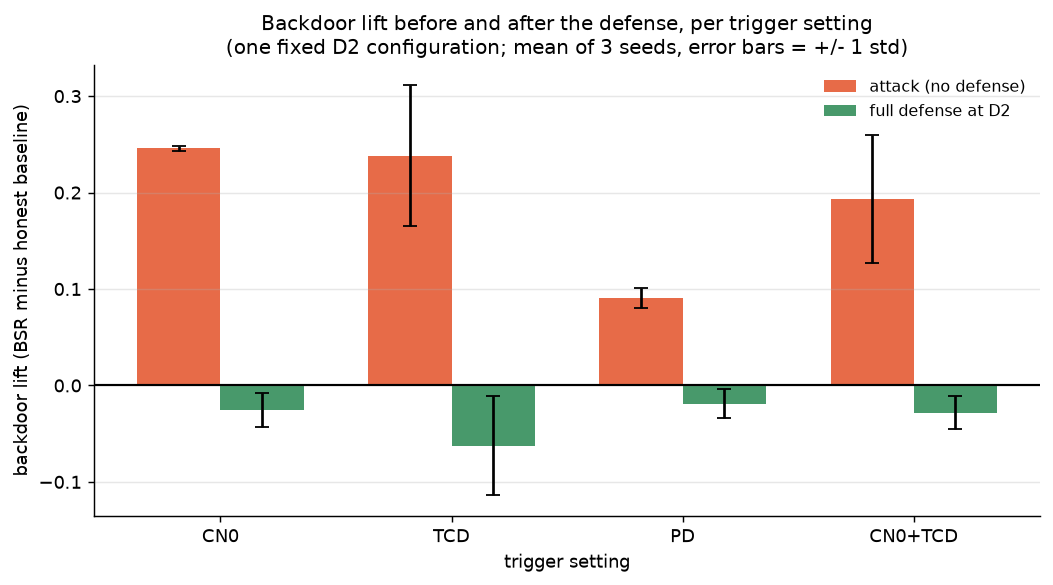

In [7]:
# ======================================================================
# Task 3 figure. Grouped bars with mean +/- std error bars, as the
# assignment requests: backdoor lift before and after the defense, per
# trigger setting.
# ======================================================================
names = list(TRIG_SETTINGS)
am = np.array([np.mean([tg[(n,sd)]['att_lift'] for sd in SEEDS]) for n in names])
asd= np.array([np.std ([tg[(n,sd)]['att_lift'] for sd in SEEDS]) for n in names])
dm = np.array([np.mean([tg[(n,sd)]['def_lift'] for sd in SEEDS]) for n in names])
dsd= np.array([np.std ([tg[(n,sd)]['def_lift'] for sd in SEEDS]) for n in names])

x = np.arange(len(names)); w = 0.36
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.bar(x-w/2, am, w, yerr=asd, capsize=4, color='#E4572E', alpha=0.88, label='attack (no defense)')
ax.bar(x+w/2, dm, w, yerr=dsd, capsize=4, color='seagreen', alpha=0.88, label='full defense at D2')
ax.axhline(0, color='black', lw=1.2)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_xlabel('trigger setting'); ax.set_ylabel('backdoor lift (BSR minus honest baseline)')
ax.set_title('Backdoor lift before and after the defense, per trigger setting\n'
             '(one fixed D2 configuration; mean of 3 seeds, error bars = +/- 1 std)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x')
fig.tight_layout(); fig.savefig(RESULTS/'fig_trigger_comparison.png', bbox_inches='tight'); plt.show()

**Table 3 and figure caption and insight.** One fixed defense configuration against four trigger settings, including a mixed CN0+TCD trigger pattern the defense was never designed around. The attack carries a viable backdoor in every setting (lift +0.09 to +0.25), and the defense drives lift below zero in every setting: CN0 -0.0253, TCD -0.0626, PD -0.0188, mixed -0.0282. Honest false positives stay between 0.3% and 0.7% of client-rounds across all settings. Two honest observations: the seed spread on the TCD and mixed rows is wide (std 0.05 to 0.07 on the attack side), and the mixed trigger's undefended BSR is the highest of all four (0.9816) even though its lift is not, because stamping two features moves the honest baseline as well. The claim this table supports is the one stated in Week 10: the defense does not require knowing the exact trigger feature, within the discriminative (probed) feature set.

## Task 3b: Adaptive (defense-aware) attacker stress test

The strongest question a reviewer can ask about a trust defense is whether a smarter attacker can slip past it. The attacker in the ablation is fixed; it poisons and scales without reacting to the coordinator. Here we test a defense-aware attacker that knows exactly how the coordinator probes and shapes its local training to evade it.

The coordinator flags a client whose spoofing recall is anomalously low on any probe slice (a discriminative feature pushed to its benign-high value). So each compromised client adds an evasion term to its local objective: on probe-style slices built from its own spoofed rows, it is trained to keep predicting spoofed, i.e. to look like the honest cohort. The evasion strength lambda is swept from 0 (the ordinary attacker) upward. This experiment is produced by `adaptive_attacker.py`; the cell below reads its exported CSV so the table cannot drift from the run.

The result is a lose-lose for the attacker, and it is structural rather than lucky. The CN0 backdoor requires the model to predict benign when CN0 is benign-high; the CN0 probe slice rewards predicting spoofed on exactly those inputs. The two objectives are direct opposites, so training to evade the probe destroys the backdoor the attacker is trying to plant.

In [ ]:
# ======================================================================
# Task 3b. Show the adaptive attacker result produced by adaptive_attacker.py.
# ======================================================================
adaptive_tab = pd.read_csv(RESULTS/'adaptive_attacker.csv')
print('Adaptive (defense-aware) attacker at D2, mean +/- std over 3 seeds')
print('lambda = evasion strength (0 is the ordinary attacker); uniform trust = 0.10\n')
print(adaptive_tab.to_string(index=False))

Adaptive (defense-aware) attacker at D2, mean +/- std over 3 seeds
lambda = evasion strength (0 is the ordinary attacker); uniform trust = 0.10

 Evasion strength (lambda)    Undefended lift Defended lift (D2) Mean attacker trust
                       0.0 +0.2457 +/- 0.0023 -0.0253 +/- 0.0178   0.0001 +/- 0.0001
                       2.0 -0.1433 +/- 0.0439 -0.0534 +/- 0.0287   0.0834 +/- 0.0017
                      10.0 -0.4782 +/- 0.0464 -0.0829 +/- 0.0304   0.0740 +/- 0.0020


**Table 4 and figure caption and insight.** The adaptive attacker cannot win. At lambda = 0 (the ordinary attacker) the undefended lift is +0.2457 and the defense holds it at -0.0253 with attacker trust 0.0001, the same picture as the ablation. As the attacker turns up evasion to look honest on the probes, its mean trust does climb toward uniform (0.0001 to 0.083 at lambda = 2, so it is genuinely evading detection better), but its undefended backdoor lift collapses to -0.14 and then to -0.48 at lambda = 10: the evasion training has destroyed its own backdoor. There is no setting where the attacker both evades the probe and keeps a working attack, because the evasion objective (predict spoofed when CN0 is benign-high) is the exact opposite of the backdoor (predict benign on those same inputs). The defended lift is negative for every lambda, so the layered defense stays intact even in the regime where the attacker partially evades the trust score. This is the direct answer to the adaptive-attacker question, produced by `adaptive_attacker.py` and saved to `results/adaptive_attacker.csv` and `results/fig_adaptive_attacker.png`.

## Scope and future work

The core research questions for this capstone are answered: the attack works and is made worse by accuracy inflation (Task 2), each defense layer contributes and only the layered defense drives lift negative while preserving utility (Task 2), the defense generalizes across the discriminative feature set including a mixed trigger (Task 3), and a defense-aware adaptive attacker cannot both evade the probe and keep a working backdoor (Task 3b). What remains is deliberately outside the scope of this study rather than unfinished within it.

1. **Base detector accuracy.** Honest spoofing recall is about 0.53 on this simplified public dataset, so absolute detection quality is modest. This is a property of the dataset and the small model, not of the defense, and it is exactly why backdoor lift against each seed's own honest baseline is the primary metric throughout. A stronger base detector is an orthogonal improvement that would not change any of the defense conclusions.

2. **Non-IID and larger fleets.** The evaluation uses ten clients, two attackers, and IID partitions. Non-IID data would widen the honest trust spread and is the setting most likely to stress the false-positive rate; scaling the fleet and relaxing the IID assumption is the natural next study. The IID choice is stated as a scope boundary, consistent with the Byzantine-robust FL literature that also assumes IID.

3. **Seed count.** Three seeds (42, 7, 123) are enough to separate the attack effect from noise and to report mean and standard deviation, which is the standard this project holds itself to; they are not enough to resolve sub-noise differences between neighbouring defended variants, and we do not claim any such difference.

4. **Triggers outside the probe set.** PQP and PIP carry near-zero class-discriminative signal (Cohen's d below 0.05) and are excluded from probing by design, so they are not tested as triggers. This is a definition of scope, not a gap: the title claim is "trigger-agnostic within the discriminative feature set," and a trigger on a feature the detector does not use would be attacking signal that is not there.

None of these affects the claims the paper makes. They are the honest limitations section every empirical paper carries, and they mark where the contribution ends rather than work left undone.